# EDA COVID-19 — Análise Exploratória de Dados

**Dataset:** Our World in Data — COVID-19  
**Disciplina:** Processamento de Grande Volume de Dados — UVV  

Este notebook realiza uma análise exploratória completa do dataset de COVID-19,
utilizando PySpark para extração e tratamento dos dados, e matplotlib/seaborn
para as visualizações.

---

## Sumário
1. [Configuração e Extração](#1)
2. [Visão Geral do Dataset](#2)
3. [Qualidade dos Dados — Valores Nulos](#3)
4. [Transformação e Limpeza](#4)
5. [Análise Global — Casos e Mortes ao Longo do Tempo](#5)
6. [Top Países por Casos e Mortes](#6)
7. [Análise por Continente](#7)
8. [Vacinação Global](#8)
9. [Taxa de Mortalidade e Fatores Socioeconômicos](#9)
10. [Taxa de Reprodução e Índice de Rigidez](#10)

## 1. Configuração e Extração <a id='1'></a>

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

warnings.filterwarnings("ignore")

# Estilo global dos gráficos
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETA = "muted"
COR_CASOS   = "#2196F3"
COR_MORTES  = "#F44336"
COR_VACINAS = "#4CAF50"

# Diretório raiz do projeto (notebook/ está um nível abaixo da raiz)
ROOT_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(ROOT_DIR, "data", "owid-covid.csv")
FIGS_DIR   = os.path.join(ROOT_DIR, "figuras")
os.makedirs(FIGS_DIR, exist_ok=True)

print(f"Dataset : {DATA_PATH}")
print(f"Figuras : {FIGS_DIR}")

Dataset : /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/data/owid-covid.csv
Figuras : /home/isabela-carone/Área de trabalho/repositorios-uvv/eda-covid19/eda-covid19/figuras


In [2]:
# Cria a SparkSession para execução local
spark = (
    SparkSession.builder
    .appName("EDA_COVID19_Notebook")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark versão: {spark.version}")
print(f"Master     : {spark.sparkContext.master}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/10 19:09:35 WARN Utils: Your hostname, isabela-carone-G3-3500, resolves to a loopback address: 127.0.1.1; using 192.168.0.14 instead (on interface enp59s0)
26/04/10 19:09:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/04/10 19:09:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark versão: 4.1.1
Master     : local[*]


In [3]:
# Leitura do CSV com PySpark — inferência automática de schema
df_bruto = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(DATA_PATH)
)
# Converte a coluna date para DateType
df_bruto = df_bruto.withColumn("date", F.to_date(F.col("date"), "yyyy-MM-dd"))

print(f"Linhas   : {df_bruto.count():,}")
print(f"Colunas  : {len(df_bruto.columns)}")


[Stage 1:====>                                                    (1 + 11) / 12]



Linhas   : 570,606
Colunas  : 61


## 2. Visão Geral do Dataset <a id='2'></a>

In [4]:
# Schema do DataFrame
df_bruto.printSchema()

root
 |-- country: string (nullable = true)
 |-- date: date (nullable = true)
 |-- total_cases: integer (nullable = true)
 |-- new_cases: integer (nullable = true)
 |-- new_cases_smoothed: double (nullable = true)
 |-- total_cases_per_million: double (nullable = true)
 |-- new_cases_per_million: double (nullable = true)
 |-- new_cases_smoothed_per_million: double (nullable = true)
 |-- total_deaths: integer (nullable = true)
 |-- new_deaths: integer (nullable = true)
 |-- new_deaths_smoothed: double (nullable = true)
 |-- total_deaths_per_million: double (nullable = true)
 |-- new_deaths_per_million: double (nullable = true)
 |-- new_deaths_smoothed_per_million: double (nullable = true)
 |-- excess_mortality: double (nullable = true)
 |-- excess_mortality_cumulative: double (nullable = true)
 |-- excess_mortality_cumulative_absolute: double (nullable = true)
 |-- excess_mortality_cumulative_per_million: double (nullable = true)
 |-- hosp_patients: integer (nullable = true)
 |-- hosp_pa

In [5]:
# Estatísticas descritivas das colunas numéricas principais
colunas_desc = [
    "total_cases", "new_cases", "total_deaths", "new_deaths",
    "total_vaccinations", "people_fully_vaccinated",
    "stringency_index", "reproduction_rate",
]
df_bruto.select(colunas_desc).describe().show(truncate=False)

+-------+--------------------+------------------+------------------+-----------------+--------------------+-----------------------+------------------+-------------------+
|summary|total_cases         |new_cases         |total_deaths      |new_deaths       |total_vaccinations  |people_fully_vaccinated|stringency_index  |reproduction_rate  |
+-------+--------------------+------------------+------------------+-----------------+--------------------+-----------------------+------------------+-------------------+
|count  |558258              |554318            |558258            |555343           |83222               |77011                  |202760            |185683             |
|mean   |1.4698134094927436E7|9810.495233782774 |158357.21636949223|93.80068174083404|5.83668210551932E8  |2.430086022758433E8    |42.675426020910976|0.9075935007512795 |
|stddev |7.551382557162964E7 |113203.16237749644|788412.9912520667 |776.037961354018 |1.8755749515849557E9|7.504499337858735E8    |24.93030475946

In [6]:
# Período coberto e diversidade geográfica
periodo = df_bruto.agg(
    F.min("date").alias("data_inicio"),
    F.max("date").alias("data_fim"),
    F.countDistinct("country").alias("total_paises"),
    F.countDistinct("continent").alias("total_continentes"),
).collect()[0]

print(f"Período      : {periodo['data_inicio']} → {periodo['data_fim']}")
print(f"Total países : {periodo['total_paises']}")
print(f"Continentes  : {periodo['total_continentes']}")


[Stage 8:====>                                                    (1 + 11) / 12]



Período      : 2020-01-01 → 2026-02-22
Total países : 262
Continentes  : 6


## 3. Qualidade dos Dados — Valores Nulos <a id='3'></a>


[Stage 17:=========>                                              (2 + 10) / 12]



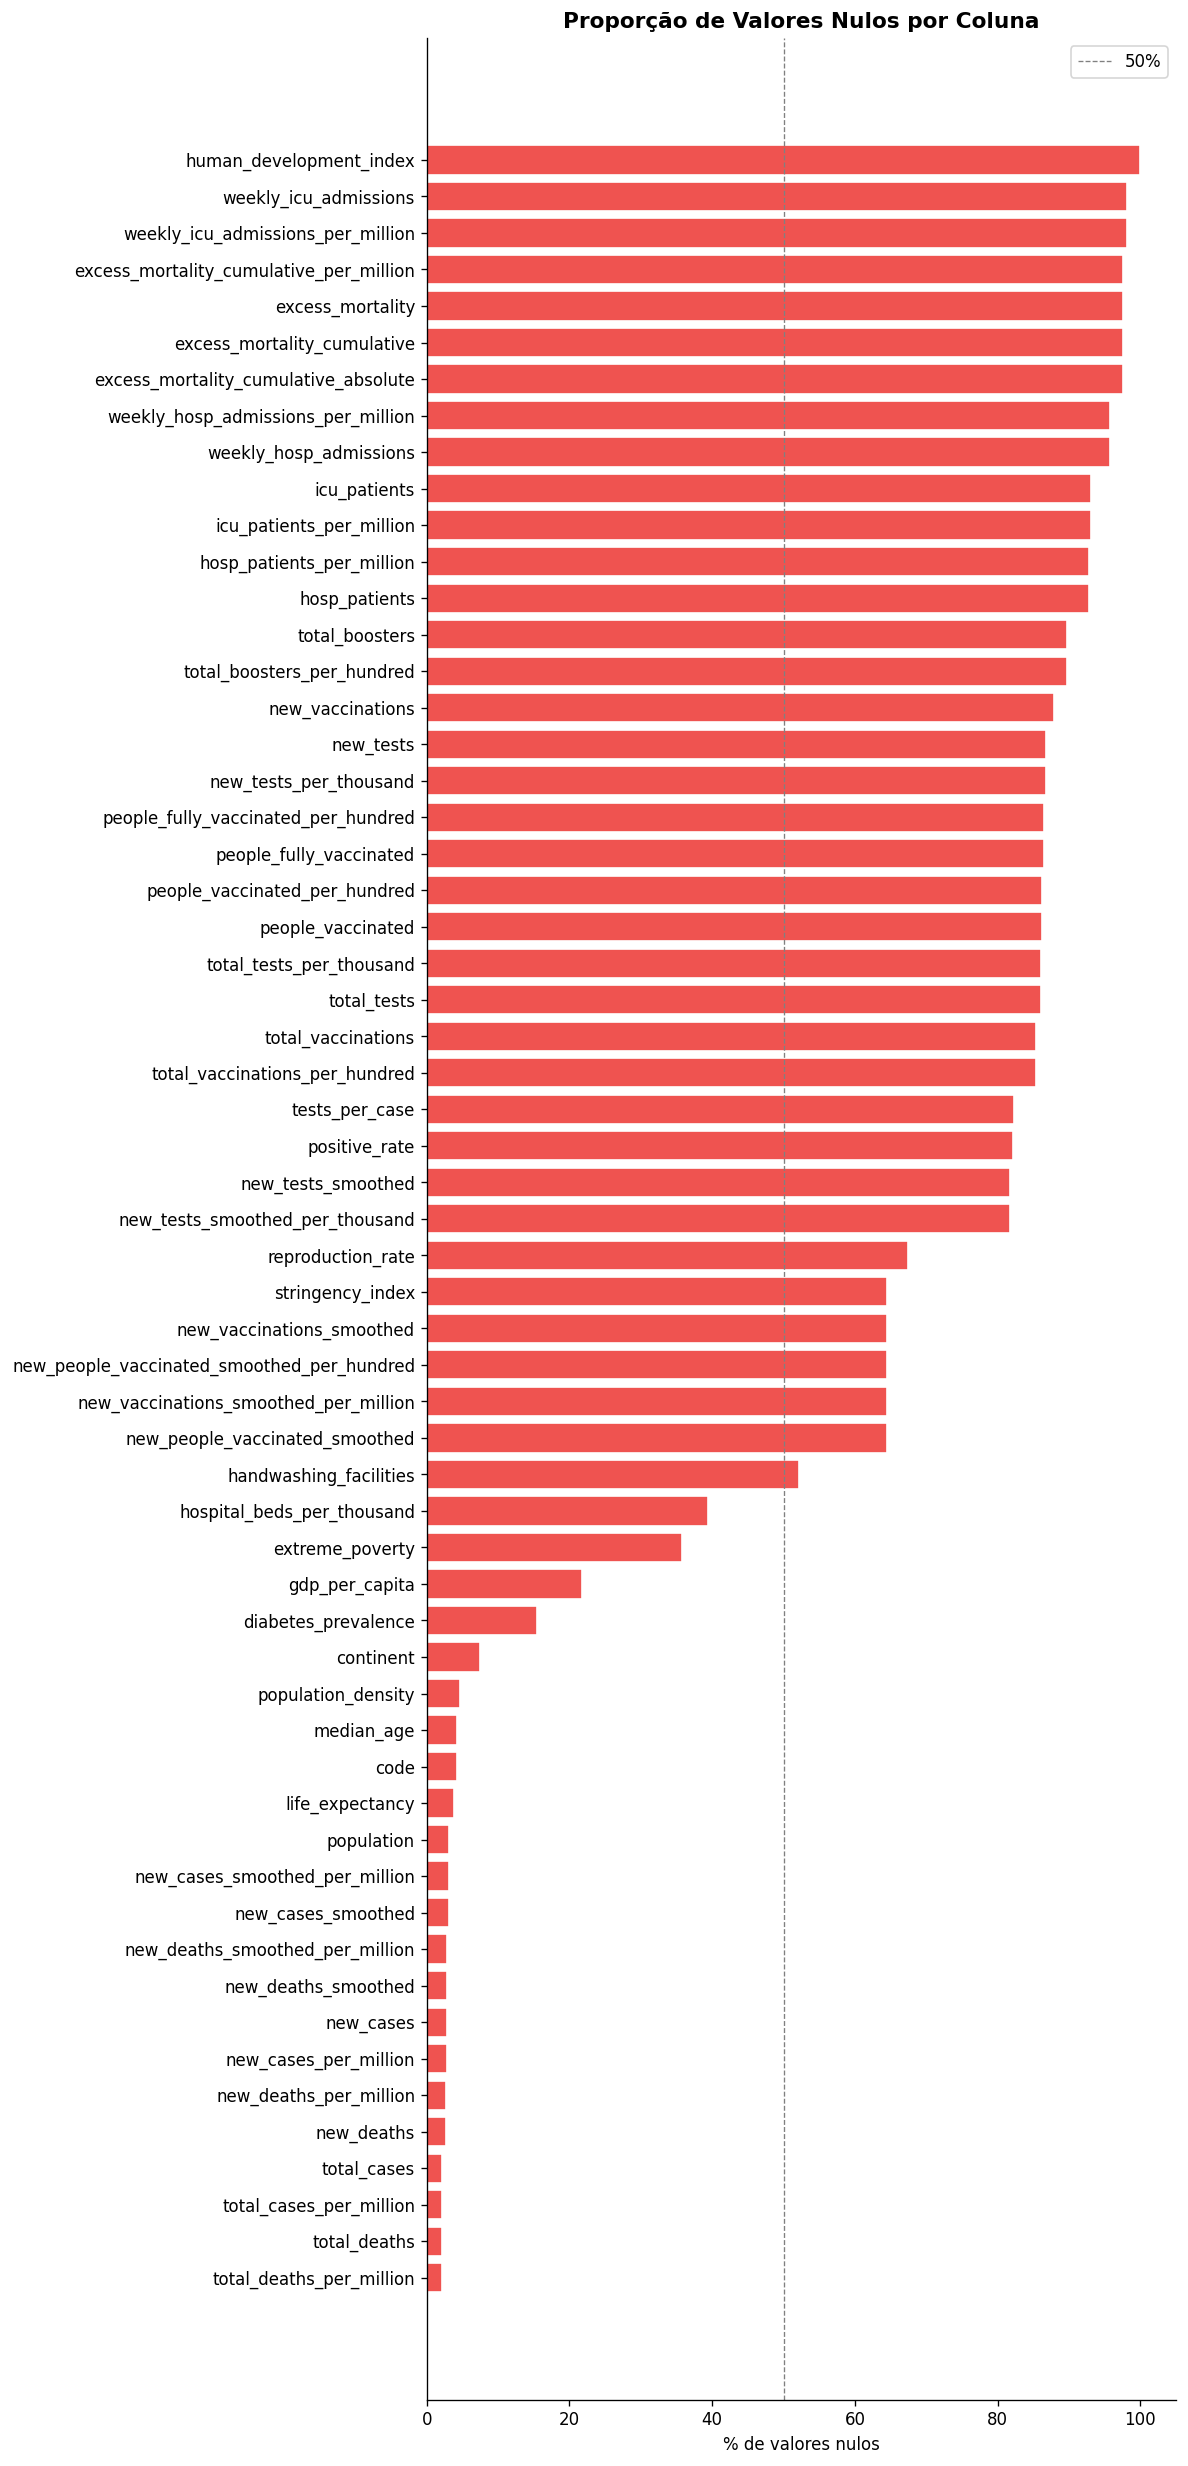

In [7]:
# Calcula a porcentagem de nulos em todas as colunas
total_linhas = df_bruto.count()

exprs_nulos = [
    (F.sum(F.col(c).isNull().cast("int")) / total_linhas * 100).alias(c)
    for c in df_bruto.columns
]
nulos_pct = df_bruto.agg(*exprs_nulos).toPandas().T
nulos_pct.columns = ["pct_nulos"]
nulos_pct = nulos_pct.sort_values("pct_nulos", ascending=False)

# Filtra colunas com ao menos 1% de nulos para o gráfico
nulos_plot = nulos_pct[nulos_pct["pct_nulos"] > 1]

fig, ax = plt.subplots(figsize=(10, max(5, len(nulos_plot) * 0.35)))
bars = ax.barh(nulos_plot.index[::-1], nulos_plot["pct_nulos"][::-1],
               color="#EF5350", edgecolor="white")
ax.set_xlabel("% de valores nulos")
ax.set_title("Proporção de Valores Nulos por Coluna", fontsize=13, fontweight="bold")
ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, label="50%")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "01_valores_nulos.png"), bbox_inches="tight")
plt.show()

## 4. Transformação e Limpeza <a id='4'></a>

In [8]:
# Regiões e agregações do OWID que não são países individuais
REGIOES_AGREGADAS = [
    "World", "Asia", "Europe", "Africa", "North America",
    "South America", "Oceania", "European Union",
    "High income", "Low income", "Lower middle income",
    "Upper middle income", "High-income countries",
]

# Mantém apenas países individuais (com continente preenchido e fora das regiões)
df_paises = (
    df_bruto
    .filter(F.col("continent").isNotNull())
    .filter(~F.col("country").isin(REGIOES_AGREGADAS))
)

# Remove valores negativos (erros de notificação)
df_limpo = (
    df_paises
    .filter((F.col("new_cases").isNull())  | (F.col("new_cases")  >= 0))
    .filter((F.col("new_deaths").isNull()) | (F.col("new_deaths") >= 0))
)

# Colunas derivadas
df = (
    df_limpo
    .withColumn("year_month",  F.date_format("date", "yyyy-MM"))
    .withColumn("year",        F.year("date"))
    # Taxa de mortalidade diária (%)
    .withColumn(
        "daily_mortality_rate",
        F.when(
            (F.col("new_cases") > 0) & F.col("new_deaths").isNotNull(),
            F.col("new_deaths") / F.col("new_cases") * 100
        )
    )
    # Vacinados completos como % da população
    .withColumn(
        "fully_vaccinated_pct",
        F.when(
            (F.col("population") > 0) & F.col("people_fully_vaccinated").isNotNull(),
            F.col("people_fully_vaccinated") / F.col("population") * 100
        )
    )
)

# Média móvel de 7 dias para casos e mortes (Window Function)
# Spark 4.x não aceita cast de DateType para BIGINT; usa unix_date() (dias desde 1970-01-01)
window_pais = (
    Window
    .partitionBy("country")
    .orderBy(F.unix_date(F.col("date")))
    .rowsBetween(-6, 0)
)
df = (
    df
    .withColumn("new_cases_ma7",  F.avg("new_cases").over(window_pais))
    .withColumn("new_deaths_ma7", F.avg("new_deaths").over(window_pais))
)

# Cache — será reutilizado em várias células
df.cache()

print(f"Registros após limpeza: {df.count():,}")
df.select(
    "country", "date", "new_cases", "new_cases_ma7",
    "new_deaths", "new_deaths_ma7", "fully_vaccinated_pct"
).show(5, truncate=False)


[Stage 20:====>                                                   (1 + 11) / 12]




[Stage 20:===================>                                     (4 + 8) / 12]




[Stage 22:=====================>                                    (3 + 5) / 8]



Registros após limpeza: 528,390


+-------+----------+---------+-------------+----------+--------------+--------------------+
|country|date      |new_cases|new_cases_ma7|new_deaths|new_deaths_ma7|fully_vaccinated_pct|
+-------+----------+---------+-------------+----------+--------------+--------------------+
|Algeria|2020-01-01|NULL     |NULL         |NULL      |NULL          |NULL                |
|Algeria|2020-01-02|NULL     |NULL         |NULL      |NULL          |NULL                |
|Algeria|2020-01-03|NULL     |NULL         |NULL      |NULL          |NULL                |
|Algeria|2020-01-04|0        |0.0          |0         |0.0           |NULL                |
|Algeria|2020-01-05|0        |0.0          |0         |0.0           |NULL                |
+-------+----------+---------+-------------+----------+--------------+--------------------+
only showing top 5 rows


## 5. Análise Global — Casos e Mortes ao Longo do Tempo <a id='5'></a>

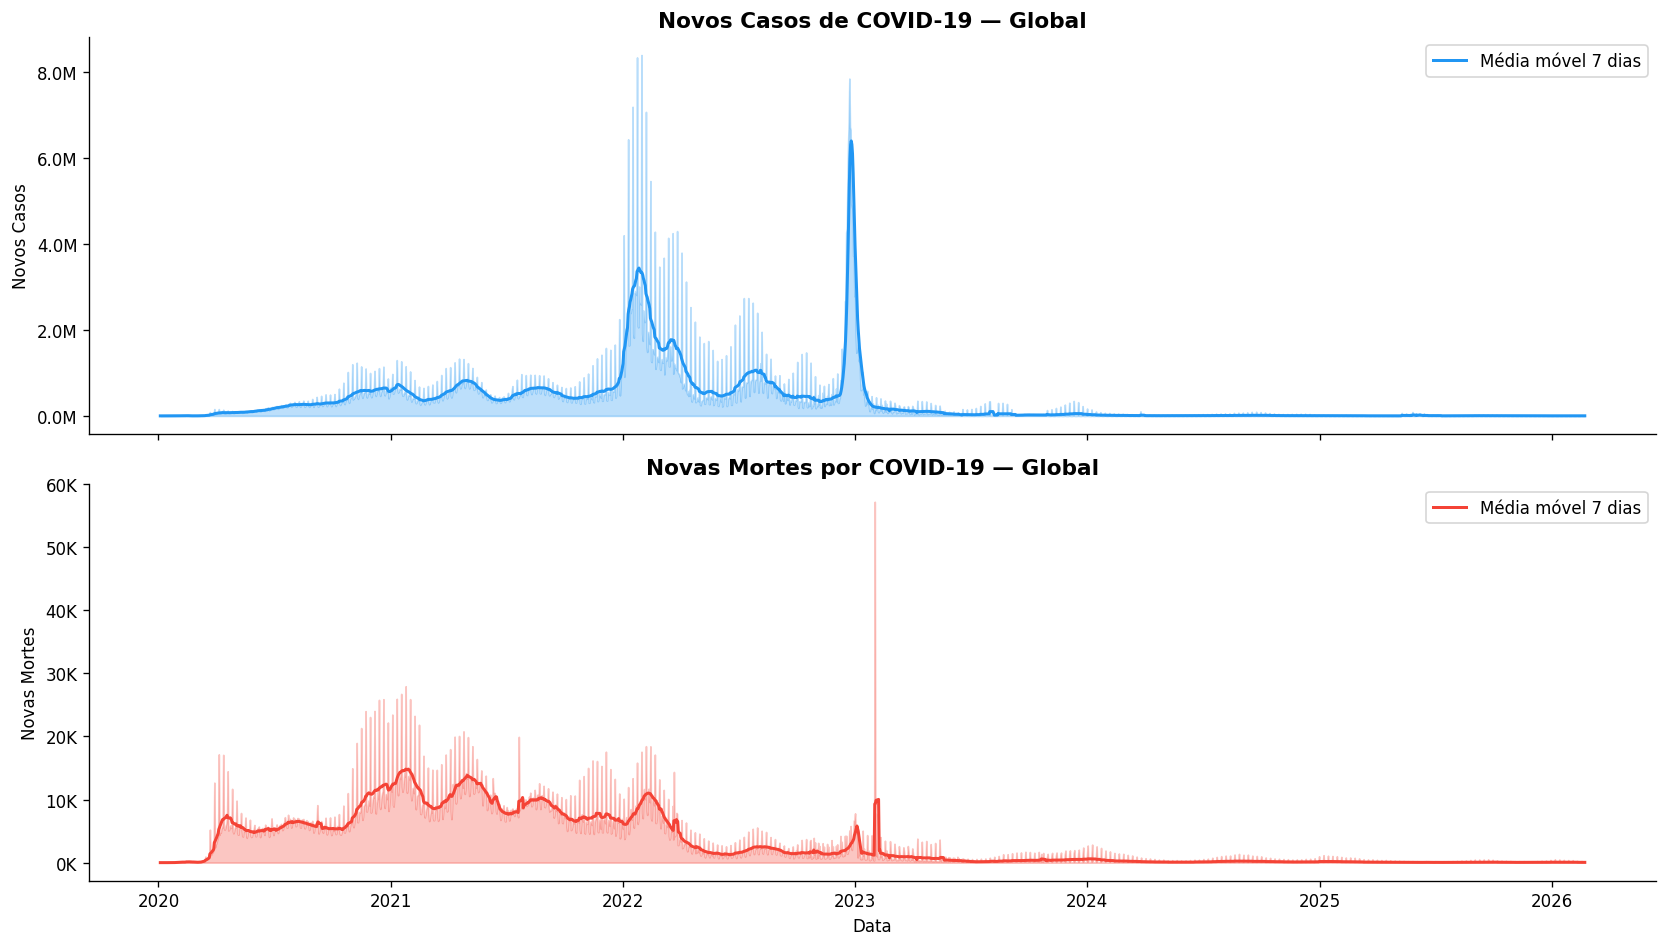

In [9]:
# Agrega casos e mortes diários globalmente
df_global_diario = (
    df
    .groupBy("date")
    .agg(
        F.sum("new_cases").alias("global_new_cases"),
        F.sum("new_deaths").alias("global_new_deaths"),
    )
    .orderBy("date")
    .toPandas()
)
df_global_diario["date"] = pd.to_datetime(df_global_diario["date"])

# Média móvel global de 7 dias
df_global_diario["casos_ma7"]  = df_global_diario["global_new_cases"].rolling(7, min_periods=1).mean()
df_global_diario["mortes_ma7"] = df_global_diario["global_new_deaths"].rolling(7, min_periods=1).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Casos diários
ax1.fill_between(df_global_diario["date"], df_global_diario["global_new_cases"],
                 alpha=0.3, color=COR_CASOS)
ax1.plot(df_global_diario["date"], df_global_diario["casos_ma7"],
         color=COR_CASOS, linewidth=1.8, label="Média móvel 7 dias")
ax1.set_ylabel("Novos Casos")
ax1.set_title("Novos Casos de COVID-19 — Global", fontsize=13, fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax1.legend()

# Mortes diárias
ax2.fill_between(df_global_diario["date"], df_global_diario["global_new_deaths"],
                 alpha=0.3, color=COR_MORTES)
ax2.plot(df_global_diario["date"], df_global_diario["mortes_ma7"],
         color=COR_MORTES, linewidth=1.8, label="Média móvel 7 dias")
ax2.set_ylabel("Novas Mortes")
ax2.set_xlabel("Data")
ax2.set_title("Novas Mortes por COVID-19 — Global", fontsize=13, fontweight="bold")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "02_evolucao_global.png"), bbox_inches="tight")
plt.show()

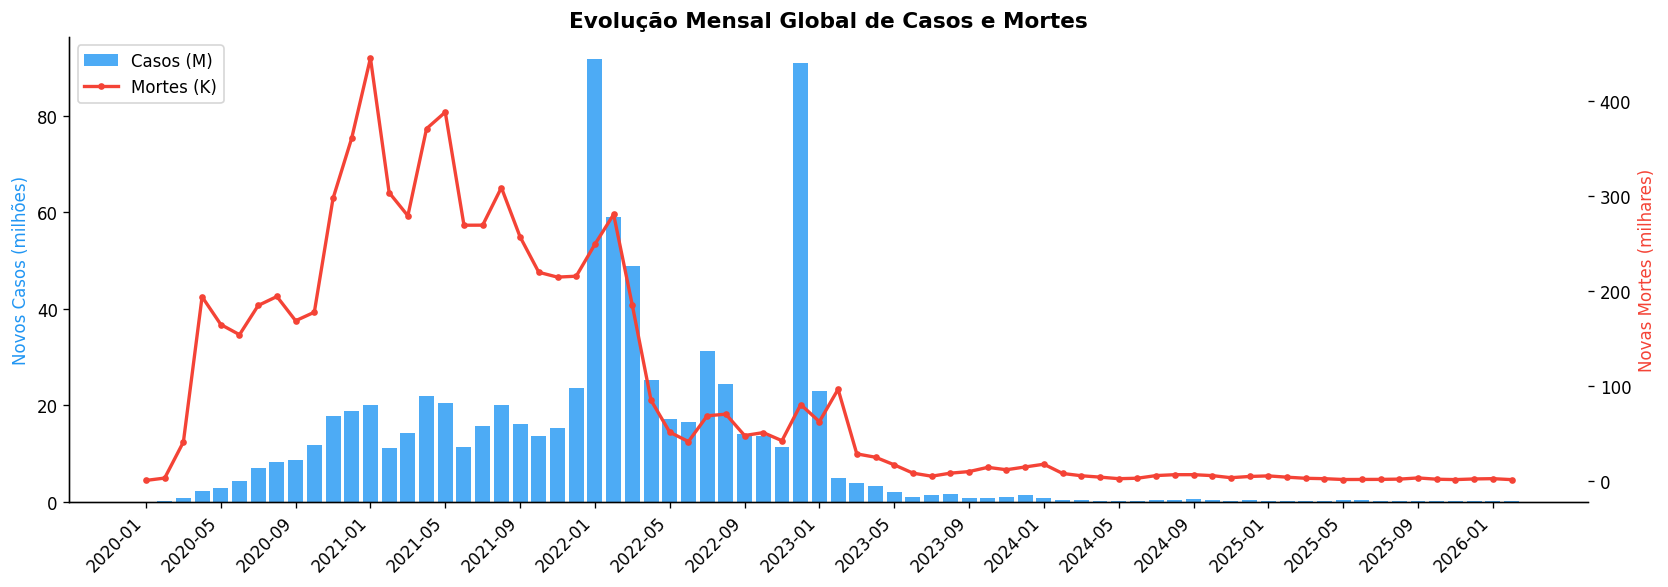

In [10]:
# Evolução mensal global de casos e mortes
df_mensal = (
    df
    .groupBy("year_month")
    .agg(
        F.sum("new_cases").alias("casos_mes"),
        F.sum("new_deaths").alias("mortes_mes"),
    )
    .orderBy("year_month")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(df_mensal))
ax.bar(x, df_mensal["casos_mes"] / 1e6, color=COR_CASOS, alpha=0.8, label="Casos (M)")

ax2 = ax.twinx()
ax2.plot(x, df_mensal["mortes_mes"] / 1e3, color=COR_MORTES,
         linewidth=2, marker="o", markersize=3, label="Mortes (K)")

# Exibe apenas alguns rótulos de data no eixo x
step = max(1, len(df_mensal) // 18)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(df_mensal["year_month"].tolist()[::step], rotation=45, ha="right")

ax.set_ylabel("Novos Casos (milhões)", color=COR_CASOS)
ax2.set_ylabel("Novas Mortes (milhares)", color=COR_MORTES)
ax.set_title("Evolução Mensal Global de Casos e Mortes", fontsize=13, fontweight="bold")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "03_evolucao_mensal.png"), bbox_inches="tight")
plt.show()

## 6. Top Países por Casos e Mortes <a id='6'></a>

In [ ]:
# Agrega totais por país (último valor acumulado disponível)
# human_development_index está como string no CSV — converte para double antes do max()
df_por_pais = (
    df
    .groupBy("country", "continent", "population")
    .agg(
        F.max("total_cases").alias("total_cases"),
        F.max("total_deaths").alias("total_deaths"),
        F.max("people_fully_vaccinated").alias("people_fully_vaccinated"),
        F.max("gdp_per_capita").alias("gdp_per_capita"),
        F.max("median_age").alias("median_age"),
        F.max(F.col("human_development_index").cast("double")).alias("hdi"),
    )
    .withColumn(
        "case_fatality_rate",
        F.when(F.col("total_cases") > 0,
               F.col("total_deaths") / F.col("total_cases") * 100)
    )
    .withColumn(
        "cases_per_million",
        F.when(F.col("population") > 0,
               F.col("total_cases") / F.col("population") * 1e6)
    )
    .withColumn(
        "deaths_per_million",
        F.when(F.col("population") > 0,
               F.col("total_deaths") / F.col("population") * 1e6)
    )
    .withColumn(
        "fully_vaccinated_pct",
        F.when(F.col("population") > 0,
               F.col("people_fully_vaccinated") / F.col("population") * 100)
    )
    .toPandas()
)

# Cores por continente para os gráficos de barra
continentes = df_por_pais["continent"].dropna().unique()
palette_cont = dict(zip(sorted(continentes), sns.color_palette(PALETA, len(continentes))))

print(f"Total de países com dados: {len(df_por_pais)}")

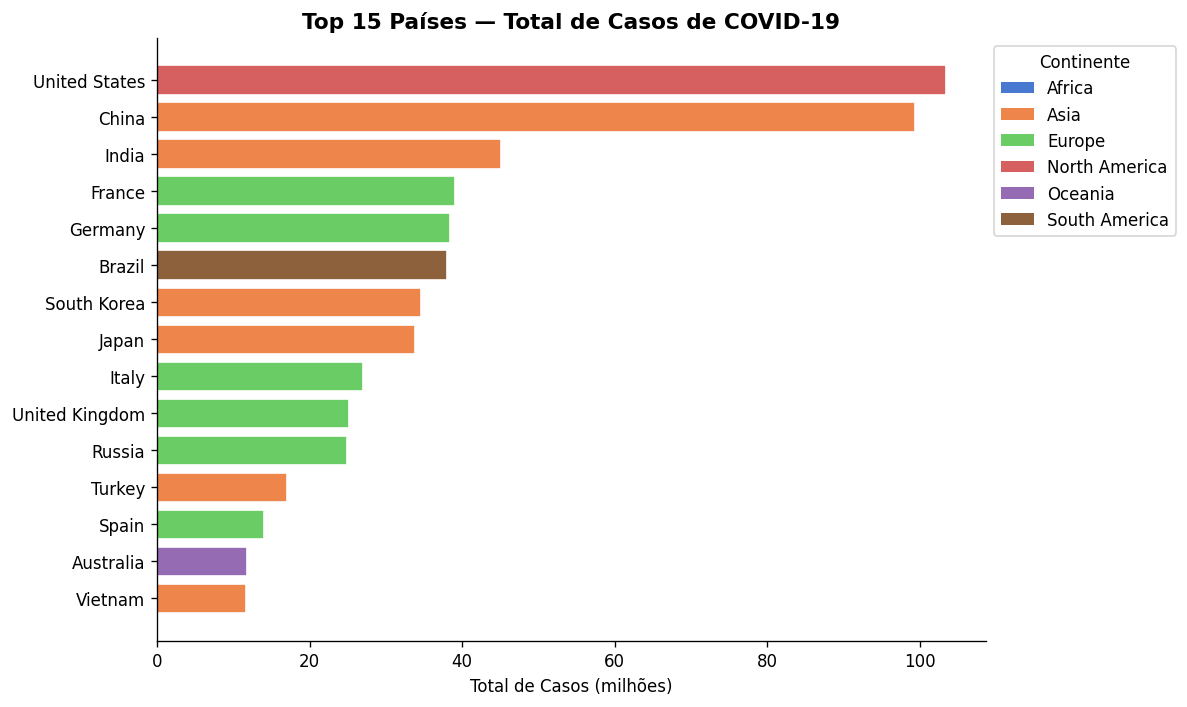

In [12]:
# Top 15 países por total de casos
top_casos = (
    df_por_pais.dropna(subset=["total_cases"])
    .nlargest(15, "total_cases")
    .sort_values("total_cases")
)

fig, ax = plt.subplots(figsize=(10, 6))
cores = [palette_cont.get(c, "gray") for c in top_casos["continent"]]
ax.barh(top_casos["country"], top_casos["total_cases"] / 1e6,
        color=cores, edgecolor="white")
ax.set_xlabel("Total de Casos (milhões)")
ax.set_title("Top 15 Países — Total de Casos de COVID-19", fontsize=13, fontweight="bold")

# Legenda de continentes
from matplotlib.patches import Patch
legenda = [Patch(facecolor=c, label=cont) for cont, c in palette_cont.items()]
ax.legend(handles=legenda, title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "04_top15_casos.png"), bbox_inches="tight")
plt.show()

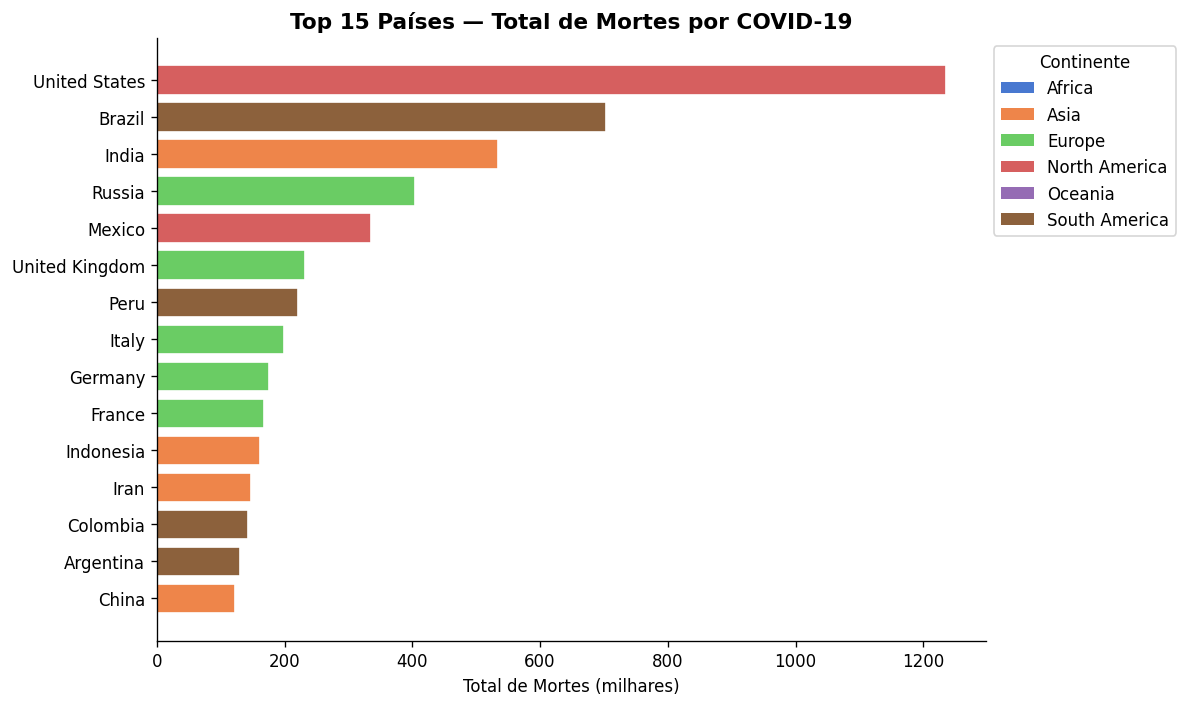

In [13]:
# Top 15 países por total de mortes
top_mortes = (
    df_por_pais.dropna(subset=["total_deaths"])
    .nlargest(15, "total_deaths")
    .sort_values("total_deaths")
)

fig, ax = plt.subplots(figsize=(10, 6))
cores = [palette_cont.get(c, "gray") for c in top_mortes["continent"]]
ax.barh(top_mortes["country"], top_mortes["total_deaths"] / 1e3,
        color=cores, edgecolor="white")
ax.set_xlabel("Total de Mortes (milhares)")
ax.set_title("Top 15 Países — Total de Mortes por COVID-19", fontsize=13, fontweight="bold")

legenda = [Patch(facecolor=c, label=cont) for cont, c in palette_cont.items()]
ax.legend(handles=legenda, title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "05_top15_mortes.png"), bbox_inches="tight")
plt.show()

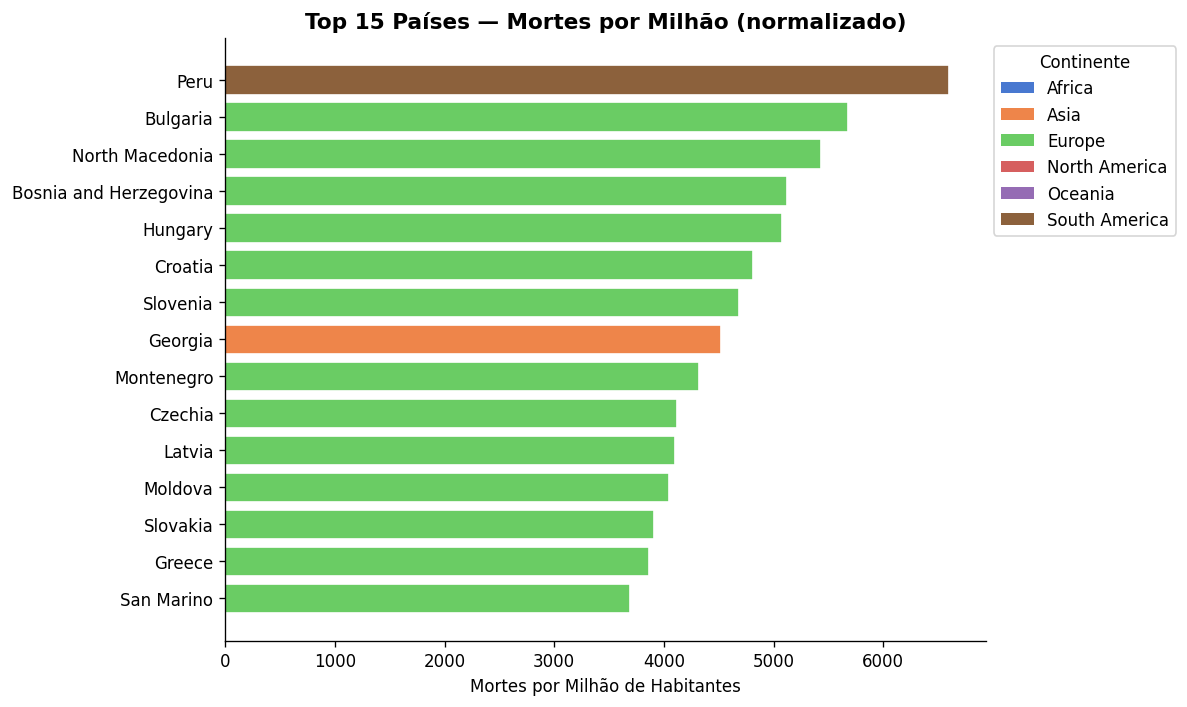

In [14]:
# Top 15 países por mortes por milhão de habitantes
top_mortes_pm = (
    df_por_pais.dropna(subset=["deaths_per_million"])
    .nlargest(15, "deaths_per_million")
    .sort_values("deaths_per_million")
)

fig, ax = plt.subplots(figsize=(10, 6))
cores = [palette_cont.get(c, "gray") for c in top_mortes_pm["continent"]]
ax.barh(top_mortes_pm["country"], top_mortes_pm["deaths_per_million"],
        color=cores, edgecolor="white")
ax.set_xlabel("Mortes por Milhão de Habitantes")
ax.set_title("Top 15 Países — Mortes por Milhão (normalizado)",
             fontsize=13, fontweight="bold")

legenda = [Patch(facecolor=c, label=cont) for cont, c in palette_cont.items()]
ax.legend(handles=legenda, title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "06_top15_mortes_por_milhao.png"), bbox_inches="tight")
plt.show()

## 7. Análise por Continente <a id='7'></a>

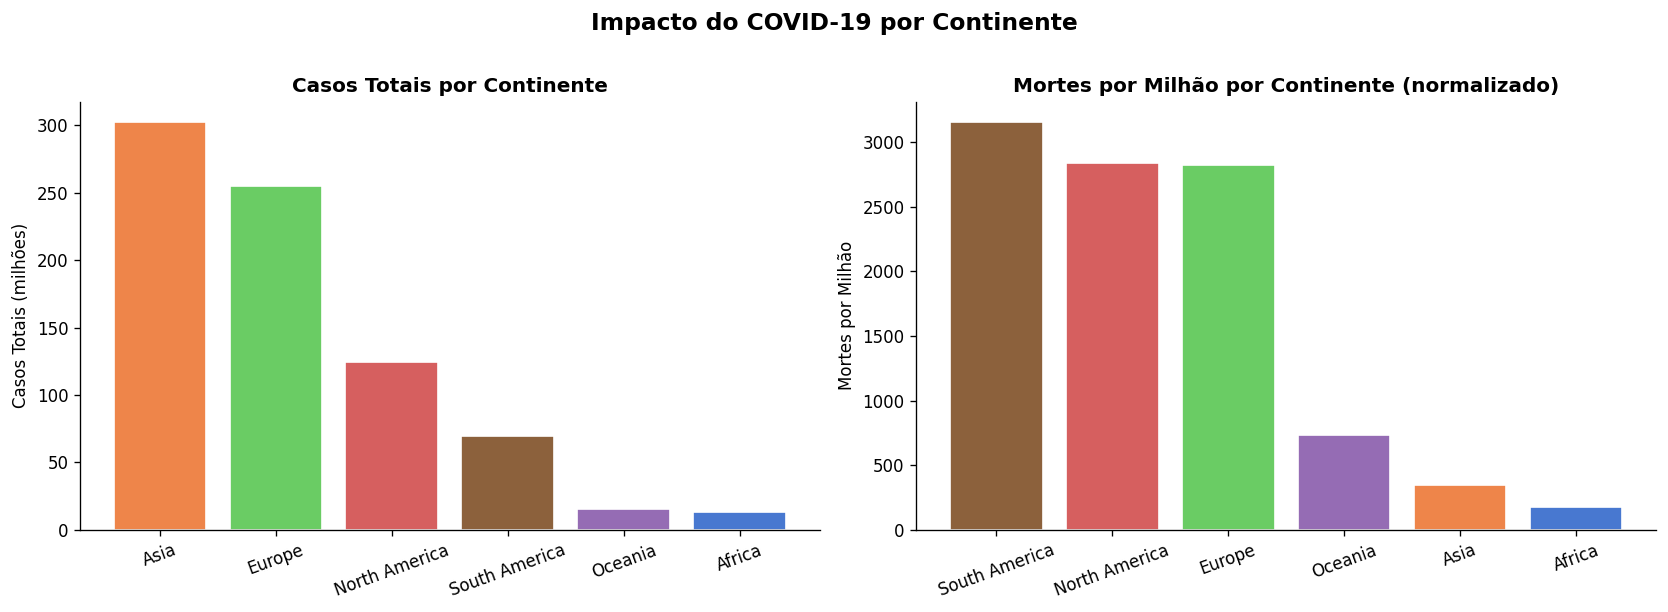

In [15]:
# Totais por continente
df_continente = (
    df_por_pais.dropna(subset=["continent"])
    .groupby("continent", as_index=False)
    .agg(
        total_cases=("total_cases", "sum"),
        total_deaths=("total_deaths", "sum"),
        population=("population", "sum"),
    )
)
df_continente["cases_per_million"]  = df_continente["total_cases"]  / df_continente["population"] * 1e6
df_continente["deaths_per_million"] = df_continente["total_deaths"] / df_continente["population"] * 1e6
df_continente = df_continente.sort_values("total_cases", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Casos totais por continente
cores_cont = [palette_cont.get(c, "gray") for c in df_continente["continent"]]
axes[0].bar(df_continente["continent"], df_continente["total_cases"] / 1e6,
            color=cores_cont, edgecolor="white")
axes[0].set_ylabel("Casos Totais (milhões)")
axes[0].set_title("Casos Totais por Continente", fontsize=12, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

# Mortes por milhão por continente
df_cont_sorted = df_continente.sort_values("deaths_per_million", ascending=False)
cores_cont2 = [palette_cont.get(c, "gray") for c in df_cont_sorted["continent"]]
axes[1].bar(df_cont_sorted["continent"], df_cont_sorted["deaths_per_million"],
            color=cores_cont2, edgecolor="white")
axes[1].set_ylabel("Mortes por Milhão")
axes[1].set_title("Mortes por Milhão por Continente (normalizado)",
                  fontsize=12, fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Impacto do COVID-19 por Continente", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "07_analise_continentes.png"), bbox_inches="tight")
plt.show()

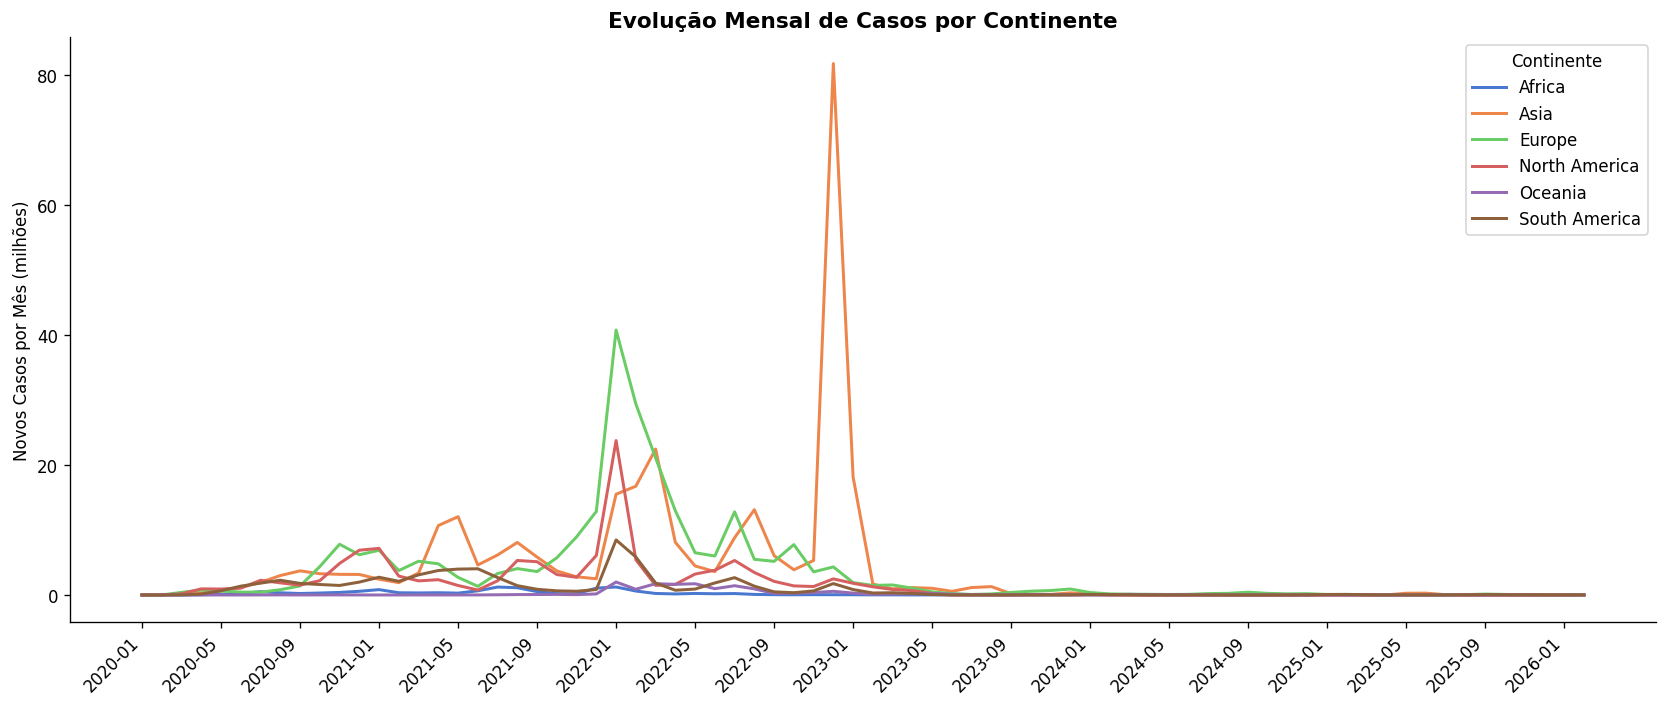

In [16]:
# Evolução de casos por continente ao longo do tempo
df_cont_tempo = (
    df
    .groupBy("year_month", "continent")
    .agg(F.sum("new_cases").alias("casos_mes"))
    .orderBy("year_month")
    .toPandas()
)

df_pivot = df_cont_tempo.pivot(index="year_month", columns="continent", values="casos_mes").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for continente in df_pivot.columns:
    cor = palette_cont.get(continente, "gray")
    ax.plot(df_pivot.index, df_pivot[continente] / 1e6,
            label=continente, color=cor, linewidth=1.8)

step = max(1, len(df_pivot) // 18)
ax.set_xticks(df_pivot.index[::step])
ax.set_xticklabels(df_pivot.index[::step], rotation=45, ha="right")

ax.set_ylabel("Novos Casos por Mês (milhões)")
ax.set_title("Evolução Mensal de Casos por Continente", fontsize=13, fontweight="bold")
ax.legend(title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "08_casos_por_continente_tempo.png"), bbox_inches="tight")
plt.show()

## 8. Vacinação Global <a id='8'></a>

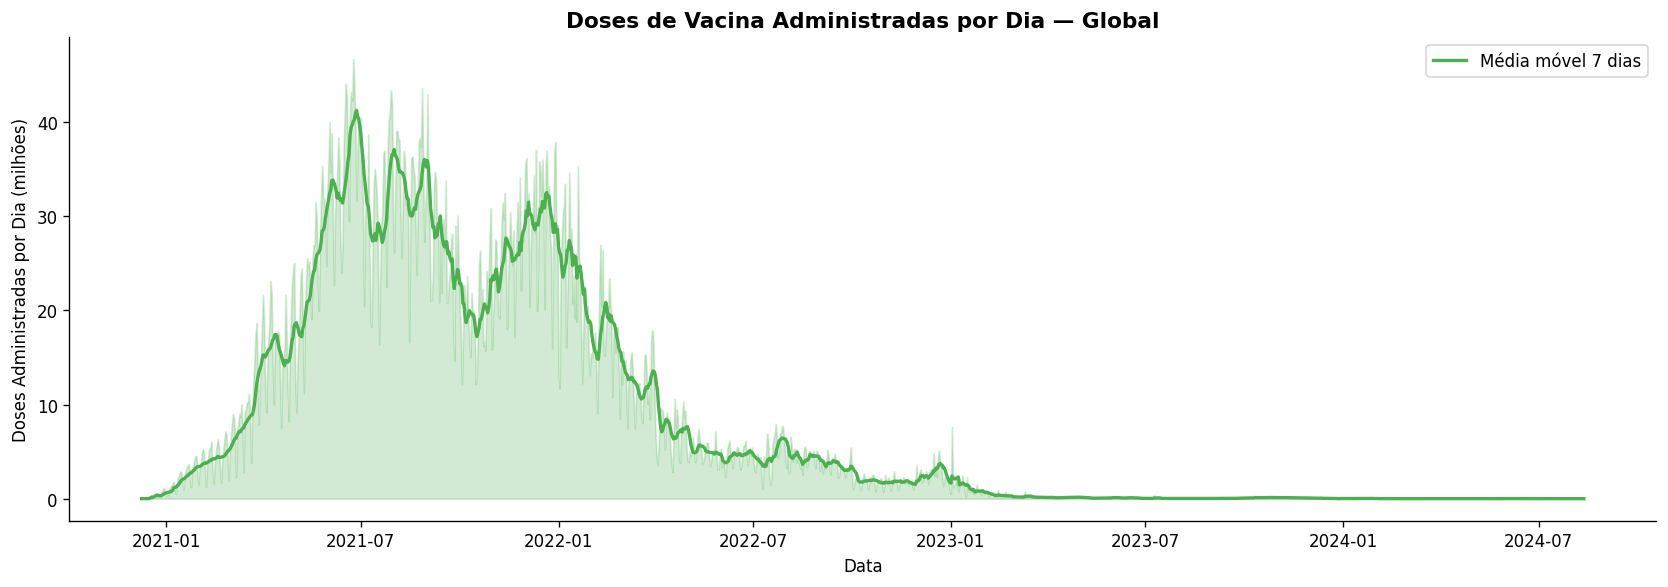

In [17]:
# Evolução da vacinação global ao longo do tempo
df_vacinas_tempo = (
    df
    .filter(F.col("new_vaccinations").isNotNull())
    .groupBy("date")
    .agg(F.sum("new_vaccinations").alias("doses_dia"))
    .orderBy("date")
    .toPandas()
)
df_vacinas_tempo["date"] = pd.to_datetime(df_vacinas_tempo["date"])
df_vacinas_tempo["doses_ma7"] = df_vacinas_tempo["doses_dia"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df_vacinas_tempo["date"], df_vacinas_tempo["doses_dia"] / 1e6,
                alpha=0.25, color=COR_VACINAS)
ax.plot(df_vacinas_tempo["date"], df_vacinas_tempo["doses_ma7"] / 1e6,
        color=COR_VACINAS, linewidth=2, label="Média móvel 7 dias")
ax.set_ylabel("Doses Administradas por Dia (milhões)")
ax.set_xlabel("Data")
ax.set_title("Doses de Vacina Administradas por Dia — Global", fontsize=13, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "09_vacinacao_global.png"), bbox_inches="tight")
plt.show()

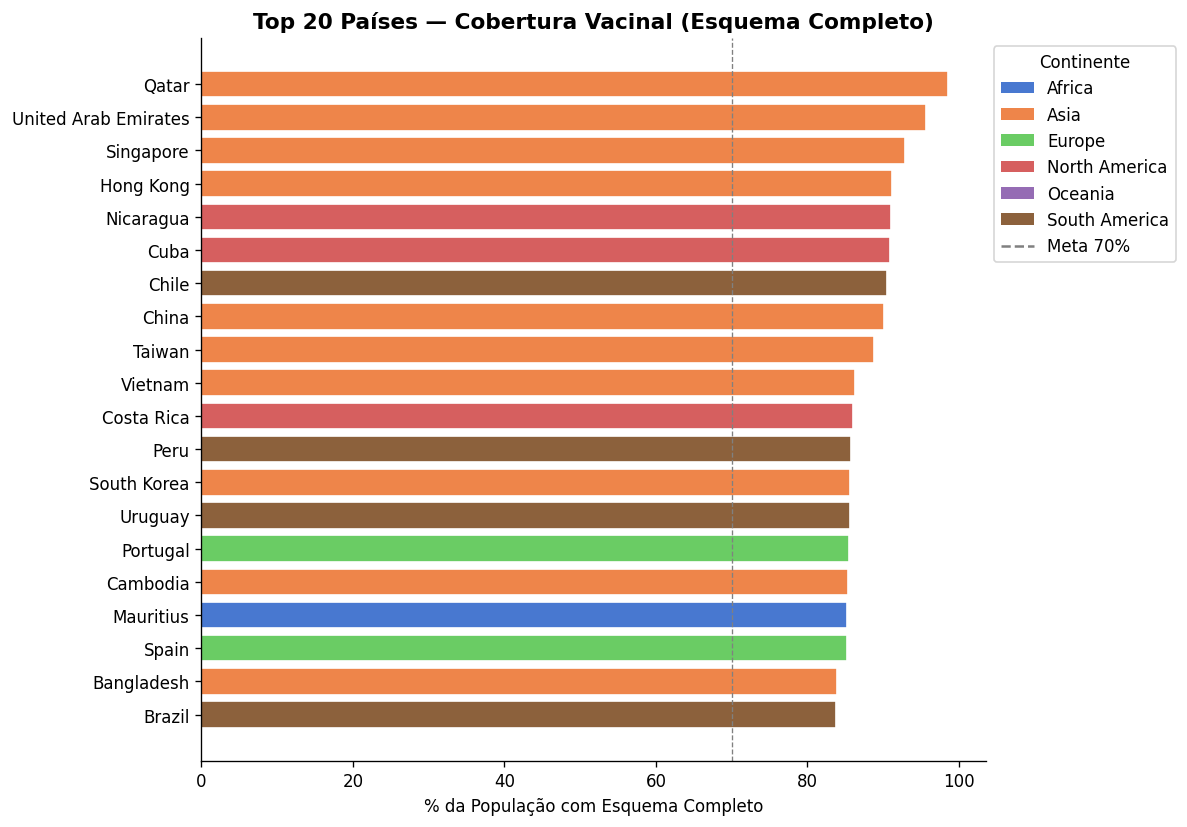

In [18]:
# Top 20 países por percentual de vacinados com esquema completo
top_vacinas = (
    df_por_pais.dropna(subset=["fully_vaccinated_pct"])
    .query("population > 1_000_000")   # exclui países muito pequenos
    .nlargest(20, "fully_vaccinated_pct")
    .sort_values("fully_vaccinated_pct")
)

fig, ax = plt.subplots(figsize=(10, 7))
cores = [palette_cont.get(c, "gray") for c in top_vacinas["continent"]]
bars = ax.barh(top_vacinas["country"], top_vacinas["fully_vaccinated_pct"],
               color=cores, edgecolor="white")
ax.axvline(70, color="gray", linestyle="--", linewidth=0.8, label="Meta 70% (OMS)")
ax.set_xlabel("% da População com Esquema Completo")
ax.set_title("Top 20 Países — Cobertura Vacinal (Esquema Completo)",
             fontsize=13, fontweight="bold")

legenda = [Patch(facecolor=c, label=cont) for cont, c in palette_cont.items()]
legenda.append(plt.Line2D([0], [0], color="gray", linestyle="--", label="Meta 70%"))
ax.legend(handles=legenda, title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "10_top20_vacinacao.png"), bbox_inches="tight")
plt.show()

## 9. Taxa de Mortalidade e Fatores Socioeconômicos <a id='9'></a>

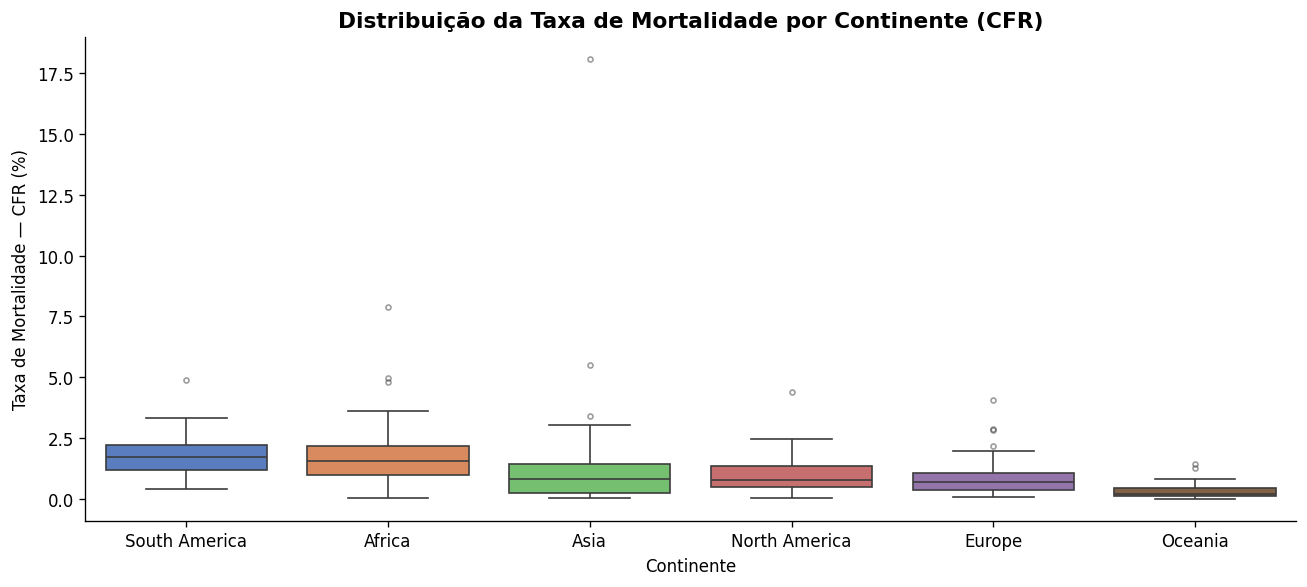

In [19]:
# Taxa de mortalidade (CFR) por continente — boxplot
df_cfr = (
    df_por_pais
    .dropna(subset=["case_fatality_rate", "continent"])
    .query("case_fatality_rate > 0 and case_fatality_rate < 30")
)

fig, ax = plt.subplots(figsize=(11, 5))
ordem_cont = df_cfr.groupby("continent")["case_fatality_rate"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_cfr, x="continent", y="case_fatality_rate",
    order=ordem_cont, palette=PALETA, ax=ax,
    flierprops=dict(marker="o", markersize=3, alpha=0.5)
)
ax.set_xlabel("Continente")
ax.set_ylabel("Taxa de Mortalidade — CFR (%)")
ax.set_title("Distribuição da Taxa de Mortalidade por Continente (CFR)",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "11_cfr_continente.png"), bbox_inches="tight")
plt.show()

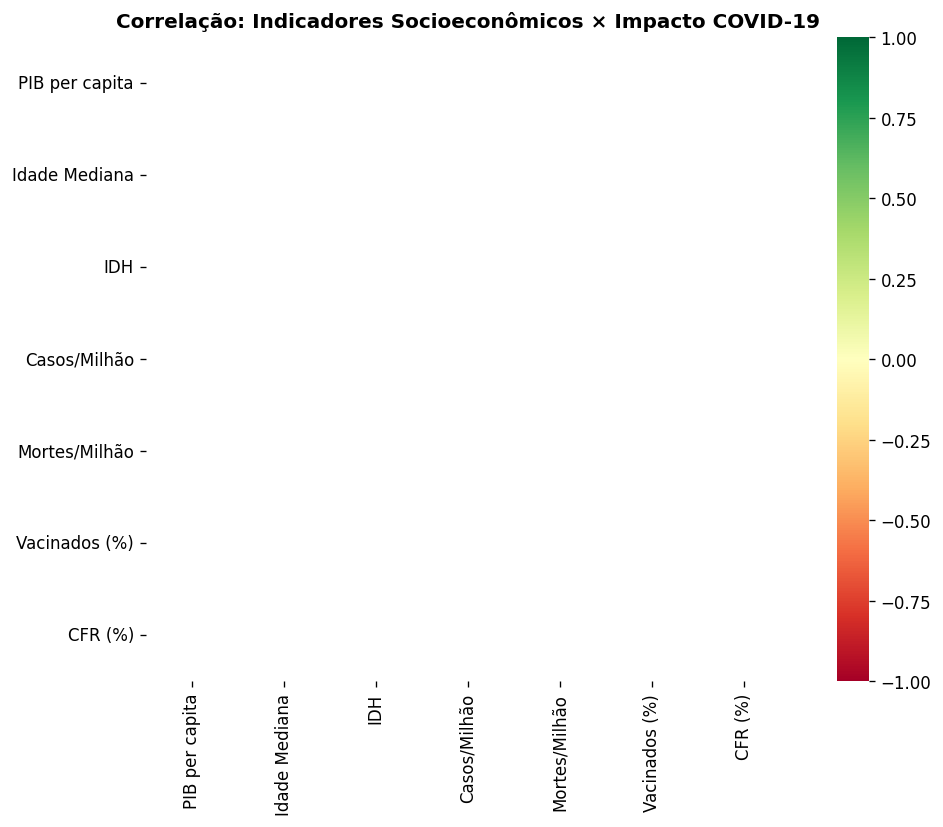

In [20]:
# Correlação entre indicadores socioeconômicos e impacto do COVID
colunas_corr = [
    "gdp_per_capita", "median_age", "hdi",
    "cases_per_million", "deaths_per_million", "fully_vaccinated_pct",
    "case_fatality_rate",
]
# Rótulos mais legíveis
labels_corr = {
    "gdp_per_capita":      "PIB per capita",
    "median_age":          "Idade Mediana",
    "hdi":                 "IDH",
    "cases_per_million":   "Casos/Milhão",
    "deaths_per_million":  "Mortes/Milhão",
    "fully_vaccinated_pct": "Vacinados (%)",
    "case_fatality_rate":  "CFR (%)",
}

df_corr = (
    df_por_pais[colunas_corr]
    .dropna()
    .rename(columns=labels_corr)
    .corr()
)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(
    df_corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Correlação: Indicadores Socioeconômicos × Impacto COVID-19",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "12_correlacao_socioeconomica.png"), bbox_inches="tight")
plt.show()

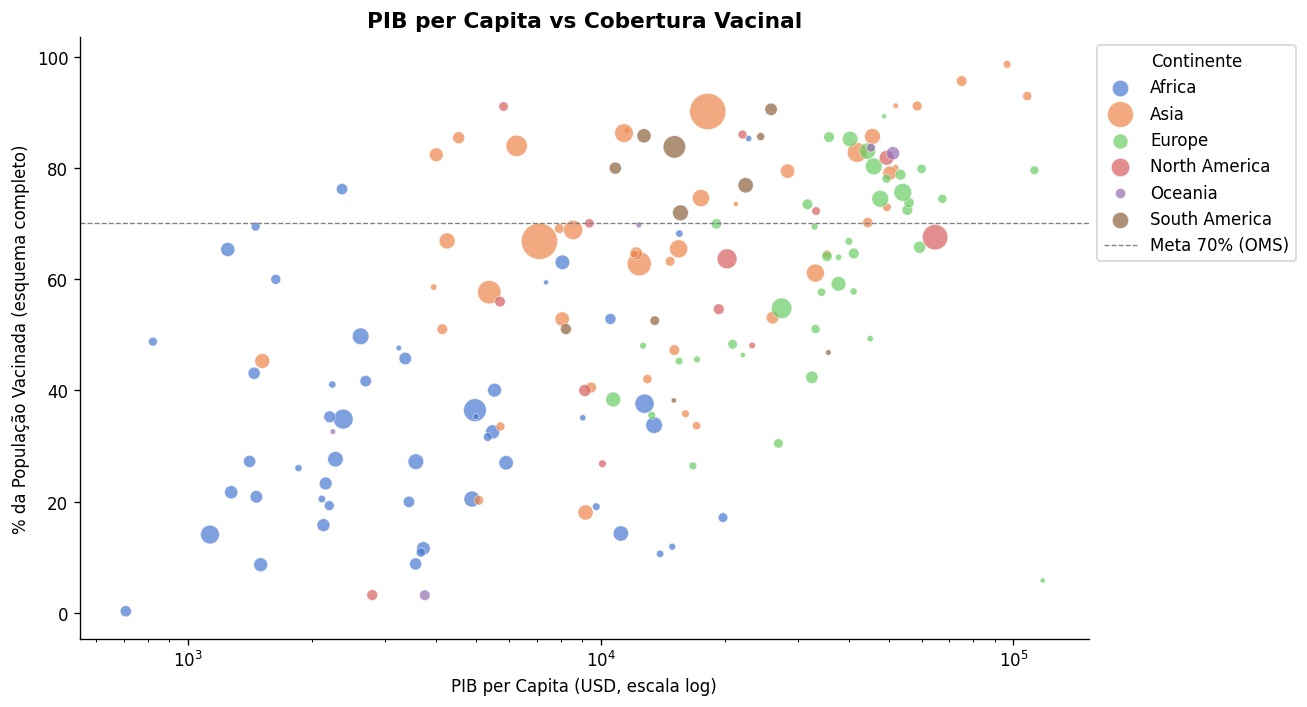

In [21]:
# Scatter: PIB per capita vs Vacinação (tamanho = população)
df_scatter = (
    df_por_pais
    .dropna(subset=["gdp_per_capita", "fully_vaccinated_pct", "population", "continent"])
    .query("population > 500_000")
)

fig, ax = plt.subplots(figsize=(11, 6))
for continente, grupo in df_scatter.groupby("continent"):
    cor = palette_cont.get(continente, "gray")
    ax.scatter(
        grupo["gdp_per_capita"],
        grupo["fully_vaccinated_pct"],
        s=np.sqrt(grupo["population"]) / 80,
        color=cor, alpha=0.7, label=continente, edgecolors="white", linewidths=0.4
    )

ax.set_xscale("log")
ax.set_xlabel("PIB per Capita (USD, escala log)")
ax.set_ylabel("% da População Vacinada (esquema completo)")
ax.set_title("PIB per Capita vs Cobertura Vacinal",
             fontsize=13, fontweight="bold")
ax.axhline(70, color="gray", linestyle="--", linewidth=0.8, label="Meta 70% (OMS)")
ax.legend(title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "13_pib_vs_vacinacao.png"), bbox_inches="tight")
plt.show()

## 10. Taxa de Reprodução e Índice de Rigidez <a id='10'></a>


[Stage 84:>                                                         (0 + 1) / 1]



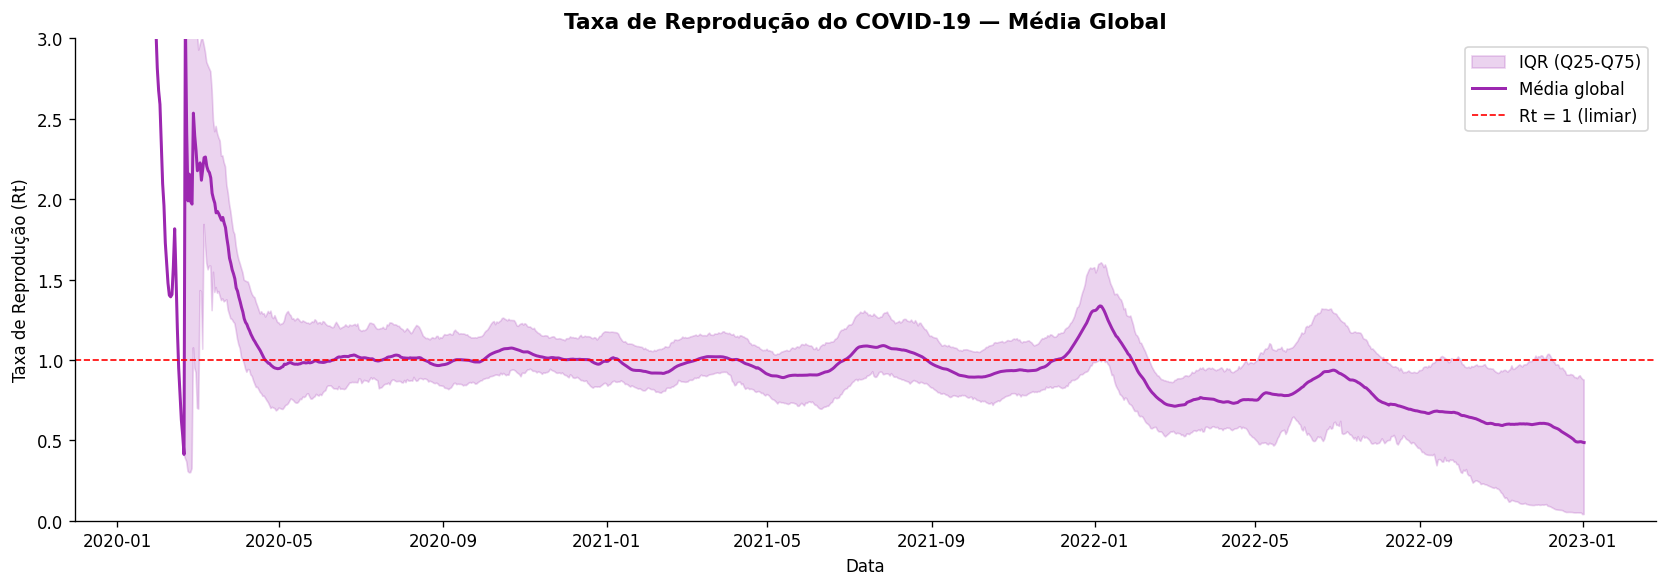

In [22]:
# Taxa de reprodução média global ao longo do tempo
df_rt_global = (
    df
    .filter(F.col("reproduction_rate").isNotNull())
    .groupBy("date")
    .agg(
        F.avg("reproduction_rate").alias("rt_media"),
        F.percentile_approx("reproduction_rate", 0.25).alias("rt_q25"),
        F.percentile_approx("reproduction_rate", 0.75).alias("rt_q75"),
    )
    .orderBy("date")
    .toPandas()
)
df_rt_global["date"] = pd.to_datetime(df_rt_global["date"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(df_rt_global["date"],
                df_rt_global["rt_q25"], df_rt_global["rt_q75"],
                alpha=0.2, color="#9C27B0", label="IQR (Q25-Q75)")
ax.plot(df_rt_global["date"], df_rt_global["rt_media"],
        color="#9C27B0", linewidth=1.8, label="Média global")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="Rt = 1 (limiar)")
ax.set_ylabel("Taxa de Reprodução (Rt)")
ax.set_xlabel("Data")
ax.set_title("Taxa de Reprodução do COVID-19 — Média Global",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 3)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "14_taxa_reproducao.png"), bbox_inches="tight")
plt.show()

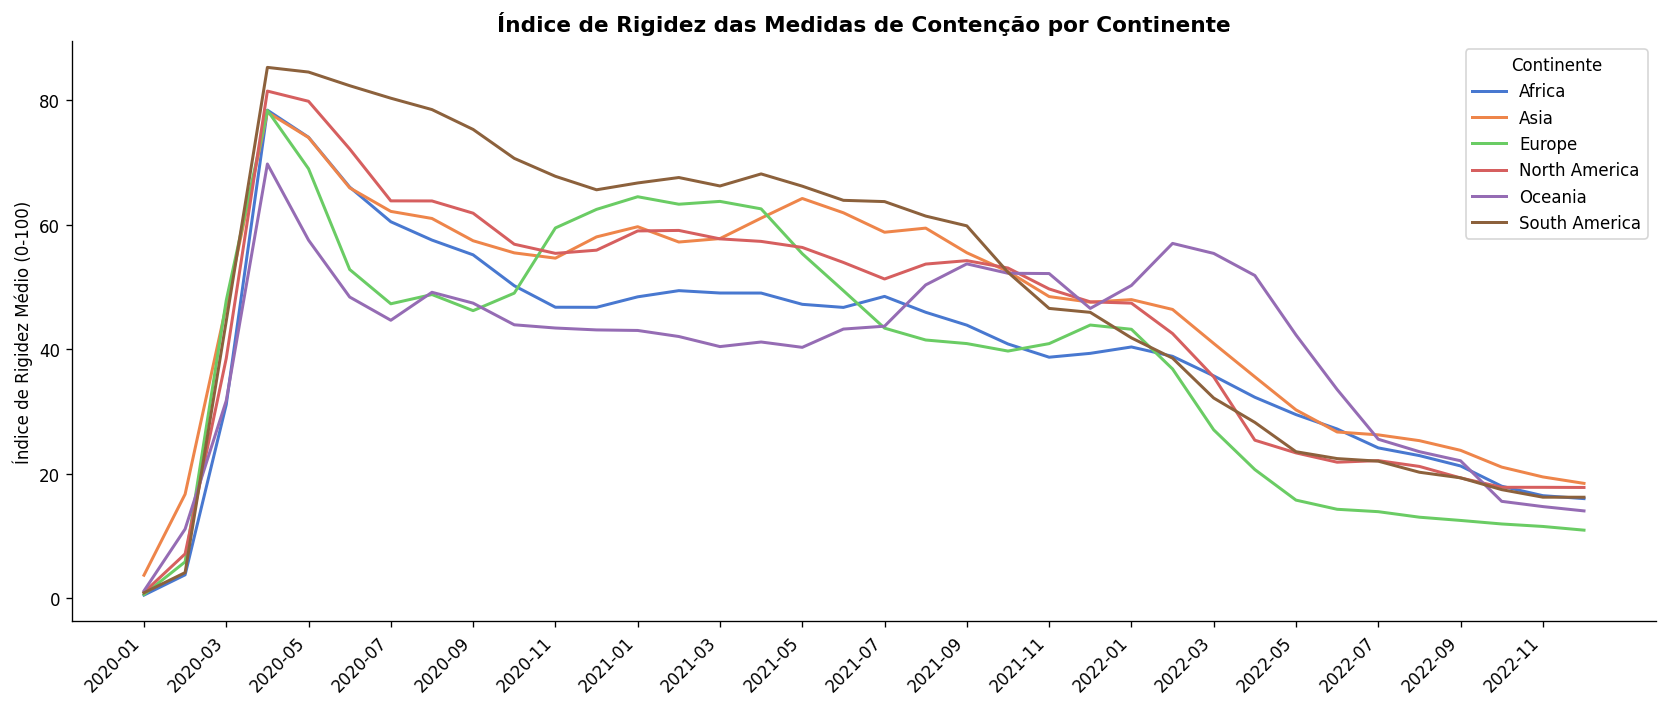

In [23]:
# Índice de rigidez médio por continente ao longo do tempo
df_rigidez = (
    df
    .filter(F.col("stringency_index").isNotNull())
    .groupBy("year_month", "continent")
    .agg(F.avg("stringency_index").alias("rigidez_media"))
    .orderBy("year_month")
    .toPandas()
)

# pandas 3.x: fillna(method=...) removido — usa ffill() diretamente
df_piv_rig = (
    df_rigidez
    .pivot(index="year_month", columns="continent", values="rigidez_media")
    .ffill()
)

fig, ax = plt.subplots(figsize=(14, 6))
for continente in df_piv_rig.columns:
    cor = palette_cont.get(continente, "gray")
    ax.plot(df_piv_rig.index, df_piv_rig[continente],
            label=continente, color=cor, linewidth=1.8)

step = max(1, len(df_piv_rig) // 18)
ax.set_xticks(df_piv_rig.index[::step])
ax.set_xticklabels(df_piv_rig.index[::step], rotation=45, ha="right")

ax.set_ylabel("Índice de Rigidez Médio (0-100)")
ax.set_title("Índice de Rigidez das Medidas de Contenção por Continente",
             fontsize=13, fontweight="bold")
ax.legend(title="Continente", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "15_indice_rigidez.png"), bbox_inches="tight")
plt.show()

In [24]:
# Encerra a SparkSession ao fim da análise
spark.stop()
print("SparkSession encerrada.")

SparkSession encerrada.
